# Übung 4

Die Forward Propagation haben Sie bereits in der letzten Übung kennengelernt. In dieser Übung werden wir Backpropagation verstehen und implementieren, um ein neuronales Netz darauf zu trainieren, handgeschriebene Ziffern zu erkennen.

Dazu implementieren Sie zunächst in Übung 4.1 die Netzwerkarchitektur und damit den Forward-Pass (Forward Propagation) sowie die Kostenfunktion. In Übung 4.2 werden Sie die Backpropagation implementieren. In Übung 4.3 trainieren Sie das neuronale Netz und suchen nach geeigneten Hyperparametern. In der optionalen Übung 4.4 beweisen Sie kurz, dass die Ableitungen, die Sie in der Backpropagation eingesetzt haben, tatsächlich stimmen.

### Hinweise

1. Die meiste Zeit werden Sie vermutlich in Aufgabe 4.2 (Implementierung der Backpropagation) verbringen. Teilen Sie sich am besten Ihre Zeit entsprechend ein.
2. In dieser Übung werden Sie mehrere Experimente durchführen. Im Laufe dieser Experimente werden Sie Berechnungen (und damit den *Kernel*) zwischenzeitlich stoppen müssen. **Wenn Sie mit Jupyter Notebook oder Jupyter Lab arbeiten, beendet das Schließen dieses Fensters nicht den Kernel!** Das bedeutet: Wenn Sie dieses Fenster schließen, werden weiterhin Berechnungen auf dem Server durchgeführt. Zum Stoppen der Berechnungen klicken Sie stattdessen im Menü auf `Kernel` > `Interrupt`. Alternativ können Sie auch im Command Mode zweimal die Taste `i` hintereinander drücken, um den Kernel zu stoppen.


### 4.1 Forward Pass

Wir werden ein neuronales Netz implementieren, das Bilder von handgeschriebenen Ziffern den Klassen 0 bis 9 zuordnen und damit klassifizieren kann. Dieses Netz unterscheidet sich etwas von dem, welches Sie in der letzten Übung kennengelernt haben, und hat die folgenden Schichten:

1. Schicht ($l_1$): Fully Connected Layer mit 100 Neuronen und **Sigmoid Aktivierungsfunktion** $\theta_1$.
2. Schicht ($l_2$): Fully Connected Layer mit 10 Neuronen und **Identitätsaktivierungsfunktion** $\theta_2 = \text{id}$.
3. Die zweite Schichte wird durch einen *Softmax* $\theta_3 = \text{softmax}$ ergänzt, sodass die Ausgaben des Netzes als Wahrscheinlichkeiten für Klassenzugehörigkeiten interpretiert werden können.

Weiterhin benennen wir:

* $s_1$: die Signale, die die Neuronen der ersten Schicht erzeugen
* $h_1=\theta_1(s_1)$: die Aktivierungen, die die Neuronen nach der Aktivierungsfunktion zeigen
* $s_2$: die Signale, die die Neuronen der zweiten Schicht erzeugen
* $h_2=\theta_3(\theta_2(s_2))$: die Aktivierungen, die die Neuronen nach der Aktivierungsfunktion zeigen. Achten Sie im nachfolgenden Quellcode besonders auf $h_2$, da es die Konvention ist, den Softmax als Teil des zweiten Layers zu betrachten und daher im Quellcode mit $h_2$ der Output des Softmax genannt wird.

Als Kostenfunktion nutzen wir die Kreuzentropie.

Die erste Schicht ($l_1$) nimmt einen Vektor der Dimension 784 entgegen. Die Ausgabe der zweiten Schicht $h_2$ ist ein Vektor mit 10 Einträgen. Die Ziffer, die das Netz vorhersagt, entspricht dem Vektorelement, das den maximalen Wert aufweist.

* Nutzen Sie lediglich Numpy, um die nachfolgenden Aufgaben zu lösen.

**Ihre Aufgaben**

(1) Führen Sie den Code in der unteren Code-Zelle aus, der die Daten importiert. Sie erhalten ein Trainingsset (train_images, train_labels), ein Validierungsset (valid_images, valid_labels) sowie ein Testset (test_images, test_labels). Die Graustufenwerte der Pixel liegen im Interval $[-1, 1]$.

In [ ]:
%matplotlib inline
import sys
import urllib.request
from io import BytesIO

import os
os.environ["KERAS_BACKEND"] = "torch" #I installed torch last time and didnt want to install tensorflow for no reason. Needing tf or torch for loading a dataset is stupid

import numpy as np
from keras.datasets import mnist
from scipy.io import loadmat


# rescaling
def rescale_reshape(image):
    temp = ((image / np.max(image)) - .5) * 2
    return temp.reshape((temp.shape[0], temp.shape[1] * temp.shape[2]))


# import data
(first_images, first_labels), (test_images, test_labels) = mnist.load_data()

# rescale and reshape data
first_images = rescale_reshape(first_images)
test_images = rescale_reshape(test_images)

# define training and validation sets
train_images, valid_images = first_images[:55000], first_images[55000:]
train_labels, valid_labels = first_labels[:55000], first_labels[55000:]

(2) Ich führe Sie durch die Implementierung der Forward Propagation. Lesen Sie dazu den Code der Funktion `forward_propagation`:

In [43]:
def forward_propagation(X, W1, b1, W2, b2):
    """Forward Propagation.

    Input:
        X: Die Trainingsdaten. Shape (samples, features)
        W1: Gewichte des Layer 1. Shape (features, n_layer1)
        W2: Gewichte des Layer 2. Shape (n_layer1, n_layer2)
        b1: Bias-Terme des Layer 1: Shape (n_layer1,)
        b2: Bias-Terme des Layer 2: Shape (n_layer2,)

    Output:
        s1: Signale des ersten Layers. Shape (samples, n_layer1)
        h1: Aktivierungen des ersten Layers. Shape (samples, n_layer1)
        s2: Signale des zweiten Layers. Shape (samples, n_layer2)
        h2: Aktivierungen des zweiten Layers. Shape (samples, n_layer2)
    """

    # Schritt 1: Berechnen Sie das Signal s1
    s1 = X@W1+b1
    # Schritt 2: Berechnen Sie die Aktivierungen h_1 des ersten Layers
    h1 = sigmoid(s1)
    # Schritt 3: Berechnen Sie das Signal s2
    s2 = h1@W2+b2
    # Schritt 4: Berechnen Sie die Aktivierungen h_2 des zweiten Layers
    h_2 = s2 #identity
    # Schritt 4b: Berechnen Sie den Output (ebenfalls h_2) der Softmax Schicht
    expy = np.exp(h_2)
    h2 = expy/np.sum(expy, axis=1, keepdims=True)
    # Wichtig: Mit `h2` bezeichnen wir im Folgenden den Output der Softmax Schicht und nicht den Output der linearen Aktivierung \theta_2, den Sie in Schritt 4 berechnet haben. Dieses Vorgehen ist zwar etwas verwirrend, aber typisch beim Umgang mit neuronalen Netzen.

    return s1, h1, s2, h2


def sigmoid(z):
    """Aktivierungsfunktion: Sigmoid

    Bitte editieren Sie diese Funktion nicht!

    """
    return 1. / (1. + np.exp(-z))

(3) Implementieren Sie in der Funktion `forward_propagation` das neuronale Netz. Ich habe Ihnen die Architektur hier noch einmal aufgeschrieben:

1. Schicht $l_1$: Fully Connected Layer mit 100 Neuronen und **Sigmoid Aktivierungsfunktion** $\theta_1$.
2. Schicht $l_2$: Fully Connected Layer mit 10 Neuronen und **Identitätsaktivierungsfunktion** $\theta_2 = \text{id}$.
3. Die zweite Schichte wird durch einen *Softmax* $\theta_3 = \text{softmax}$ ergänzt, sodass die Ausgaben des Netzes als Wahrscheinlichkeiten für Klassenzugehörigkeiten interpretiert werden können.
   - Hinweis: Es ist hilfreich, wenn Ihre Softmax-Implementierung ein Numpy Array zurückgibt, welches die Anzahl der Dimensionen erhält. Dafür ist der Numpy Schalter `keepdims=True` nützlich. Falls Sie dies an dieser Stelle jetzt noch nicht berücksichtigen wollen, dann werden Sie spätestens in der nachfolgenden Teilaufgabe auf Schwierigkeiten stoßen, und können diesen Hinweis dann hier zu Debugging-Zwecken wieder lesen.

Nutzen Sie für die Sigmoid-Aktivierungsfunktion die Funktion `sigmoid`, die ich Ihnen oben schon aufgeschrieben habe. Die Definition einer Softmax-Funktion schlagen Sie bitte in den Vorlesungsfolien nach.

(4) Führen Sie die obige Code-Zelle mit Ihrer Implementierung der Forward Propagation aus, damit sie dem Kernel dieses Notebooks bekannt wird. Testen Sie anschließend Ihre Implementierung der Forward Propagation, indem Sie sich durch die folgende Codezelle lesen und dort Ihre Implementierung überprüfen:

In [44]:
# Die Funktion forward_propagation nimmt die Variablen
#     X, W1, b1, W2, b2
# an und gibt die Variablen
#     s1, h1, s2, h2
# zurück.

# Ich importiere Ihnen Beispielinput für die Funktion und den korrekten Output:
file = urllib.request.urlopen('https://data.bialonski.de/dl/forward_propagation_test.mat')
test = loadmat(BytesIO(file.read()))

# test ist ein Dictionary, das beispielhafte Input-Variablen sowie den zugehörigen Output
# enthält. Führen Sie Ihre Forward Propagation mit den geladenen Input-Variablen durch und
# überprüfen Sie, ob Sie auf dieselben (oder innerhalb der numerischen Genauigkeit auf sehr
# ähnliche) Werte kommen wie die in test hinterlegten Output-Werte.
print(test.keys())

pls_s1, pls_h1, pls_s2, pls_h2 = forward_propagation(test["X"], test["W1"], test["b1"], test["W2"], test["b2"])
print(np.isclose(pls_s1, test["s1"]).all())
print(np.isclose(pls_s2, test["s2"]).all())
print(np.isclose(pls_h1, test["h1"]).all())
print(np.isclose(pls_h2, test["h2"]).all())


dict_keys(['__header__', '__version__', '__globals__', 'W1', 'b1', 'W2', 'b2', 's1', 'h1', 's2', 'h2', 'y_enc', 'loss', 'X'])
True
True
True
True


(5) Wir werden nun die Kostenfunktion implementieren. Es handelt sich um die Kreuzentropie. Schlagen Sie noch einmal in den Folien der heutigen Vorlesung nach, um zu sehen, wie diese definiert ist.

* Das Target (also die *ground truth* der Klassenzugehörigkeit) wird der Kostenfunktion als One-Hot kodierte Vektoren übergeben. Auch das Konzept der One-Hot Kodierung finden Sie in den Folien der heutigen Vorlesung.

Implementieren Sie dann in der unten stehenden Code-Zelle die Kostenfunktion. Bitte achten Sie dabei unbedingt auf die folgenden zwei Hinweise:

1. Die Kostenfunktion ist definiert als der Mittelwert über die Kreuzentropie der einzelnen Datenpunkte.
2. Nutzen Sie den Shape der y_enc Variablen, um die Anzahl der Datenpunkte zu bestimmen.

In [45]:
def loss_function(y_enc, output):
    """Implementierung der Loss Function (Kostenfunktion)

    Input:
        y_enc: One-Hot kodierte Klassenlabels, Shape: (n_samples, n_labels)
        output: Aktivierungen des Output Layers (= des 2. Layers)
                Dies entspricht in unserem Netz der Variablen 'h2' (Output der Softmax Funktion).

    Output:
        loss: Wert der Kostenfunktion (skalarer Wert)
    """

    # Implementieren Sie hier die Kostenfunktion

    n_samples = y_enc.shape[0]
    loss = -np.sum(y_enc * np.log(output)) / n_samples
    return loss

loss_pls = loss_function(test["y_enc"], test["h2"])
print(loss_pls)
print(test["loss"])

2.3280637038230108
[[2.3280637]]


(6) Führen Sie die obige Code-Zelle aus, um sie dem Kernel dieses Notebooks bekannt zu machen.

* Testen Sie im Anschluss, ob Sie die Kostenfunktion korrekt implementiert haben, indem Sie die Daten aus der `test` Variablen aus Teilaufgabe (4) (dort: y_enc: `test['y_enc']`, output: `test['h2']`) in Ihre Kostenfunktion stecken und den zurückgegebenen Wert mit `test['loss']` vergleichen.

Damit darf ich Ihnen gratulieren. Sie haben die Forward Propagation und die Loss Funktion erfolgreich implementiert.

### 4.2 Backpropagation


In dieser Übung implementieren wir die Backpropagation für das neuronale Netz aus Aufgabe 4.1.

Dazu gebe ich Ihnen die Ableitungen einiger Aktivierungsfunktionen (bzw. Schichten) an:

1. Ableitung der Aktivierungsfunktion $\theta_1$ (Sigmoidfunktion): $\theta_1'(s) = \theta_1(s) (1-\theta_1(s))$
2. Ableitung der Aktivierungsfunktion $\theta_2$ (Identitätsfunktion): $\theta_2'(s) = \text{id}'(s) = 1$
3. Ableitung des Kostenfunktion (Kreuzentropie) $L$ nach dem Output ($h_2$) der zweiten Schicht in Kombination mit Softmax:

   $\frac{\partial L}{\partial \vec{h}_2} = \vec{h}_2 - \vec{y}$ (wobei $\vec{y}$ der One-Hot kodierte Labelvektor ist).

Wenn Sie sich dafür interessieren, warum die obigen Ableitungen diese Gestalt haben, können Sie dies in der letzten Aufgabe dieses Notebooks untersuchen.

* Nutzen Sie lediglich Numpy, um die nachfolgenden Aufgaben zu lösen.

**Ihre Aufgaben**

(1) Nehmen Sie sich die Folien der heutigen Vorlesung zur Hand. Suchen Sie dort nach den Vorschriften für die **Backpropagation in der schicht-zentrierten Betrachtung**.

(2) Lesen Sie die nachfolgende Funktion durch, in der Sie die Backpropagation implementieren sollen:

In [50]:
def back_propagation(h1, h2, W2, X_train, y_train_enc):
    """Backward Propagation.

    Input:
        X_train: Die Trainingsdaten. Shape (samples, features)
        y_train_enc: One-Hot-kodierte Labels. Shape (samples, n_labels)
        W2: Gewichte des Layer 2. Shape (n_layer1, n_layer2)
        h1: Aktivierungen des ersten Layers. Shape (samples, n_layer1)
        h2: Aktivierungen des zweiten Layers. Shape (samples, n_layer2)

    Intermediate:
        delta1: Fehlersignal des ersten Layers. Shape (samples, n_layer1)
        delta2: Fehlersignal des zweiten Layers. Shape (samples, n_layer2)

    Output:
        dW1: Gradientenmatrix für die Gewichtsmatrix W1. Shape (features, n_layer1)
        dW2: Gradientenmatrix für die Gewichtsmatrix W2. Shape (n_layer1, n_layer2)
        db1: Gradientenvektor für die Biasterme des Layer 1. Shape (n_layer1,)
        db2: Gradientenvektor für die Biasterme des Layer 2. Shape (n_layer2,)
    """

    # Zweite Schicht
    n_samples = X_train.shape[0]

    delta2 = h2-y_train_enc
    
    dW2 = h1.T@delta2/n_samples

    db2 = np.sum(delta2, axis= 0)/ n_samples

    # Erste Schicht

    delta1 = (delta2@W2.T)*h1*(1-h1)

    dW1 = X_train.T@delta1/n_samples

    db1 = np.sum(delta1, axis=0)/n_samples

    return dW1, db1, dW2, db2

(3) Implementieren Sie die Backpropagation, indem Sie die Folie zur schicht-zentrierten Betrachtung der Backpropagation zur Hand nehmen und sich klarmachen, dass $\theta_2(\cdot) = \text{id}(\cdot)$ ist.

  * Schlagen Sie zudem die Ableitungen nach, die Ihnen zu Beginn der Aufgabe 4.2. angegeben wurden.
  * Prüfen Sie unbedingt die Dimensionen der Gradientenmatrizen dW1, dW2 sowie der Gradientenvektoren db1 und db2!

(4) Führen Sie zunächst die obige Code-Zelle aus, sodass Ihre Backpropagation-Funktion dem Kernel dieses Notebooks bekannt wird. Wir werden jetzt Ihre Implementierung debuggen. Dabei gehen wir genauso vor, wie dies auch in der Praxis gemacht wird, wenn eine Backpropagation einmal neu implementiert werden muss. (Eine Backpropagation werden Sie typischerweise dann selbst implementieren müssen, wenn bestimmte Layer-Typen oder architektonische Besonderheiten nicht in Deep-Learning Bibliotheken abbildbar sind.)

Die Idee für das Debugging ist einfach. Wir suchen uns zunächst ein beliebiges skalares Gewicht $w$ aus dem Netz aus und schreiben den Differenzenquotienten auf,

$$\frac{\partial L(w)}{\partial w} \approx \frac{L(w+\epsilon)- L(w)}{\epsilon},$$

wobei $\epsilon$ ein kleiner Wert sei (beispielsweise: $\epsilon = 10^{-10}$).

* Die linke Seite $\left(\frac{\partial L(w)}{\partial w}\right)$ bestimmen Sie über Ihre Implementierung der Backpropagation.

* Die rechte Seite bestimmen Sie, indem Sie die Kostenfunktion $L$ einmal auswerten bei $L(w+\epsilon)$ und einmal bei $L(w)$. Dies bedeutet, dass Sie zweimal eine Forward Propagation ausführen mit fast identischen Gewichtsmatrizen, wobei Sie bei einem Mal das Gewicht $w$ in der entsprechenden Gewichtsmatrix leicht verändern (indem Sie $\epsilon$ aufaddieren). Für beide Forward Propagations ermitteln Sie jeweils einen Wert für die Loss Function.

Schlussendlich vergleichen Sie, ob der durch die Backpropagation bestimmte Wert (linke Seite der Gleichung) in etwa der rechten Seite der Gleichung entspricht.

Wenn

* die linke und rechte Seite auf viele Stellen übereinstimmen, haben Sie alles richtig gemacht und können fortfahren. Es ist übrigens gute Praxis, diese Überprüfung für verschiedene Gewichte $w$ im Netz zu überprüfen.
* die linke und rechte Seite **nicht** auf viele Stellen übereinstimmt, dann haben Sie vermutlich Implementierungsfehler in der Backpropagation gemacht. Überprüfen Sie Ihre Implementierung entsprechend.

Nutzen Sie die Daten aus Teilaufgabe 4.1.4 (`test`) für die Überprüfung der Backpropagation in der folgenden Code-Zelle:

In [51]:
# unperturbed case: determining dL/dw and L(w)
s1, h1, s2, h2 = forward_propagation(test['X'], test['W1'], test['b1'], test['W2'], test['b2'])
loss_unperturbed = loss_function(test['y_enc'], h2)
dW1, db1, dW2, db2 = back_propagation(h1, h2, test['W2'], test['X'], test['y_enc'])

# perturbed case: determining L(w+eps)
epsilon = 0.000000001
W1_perturbed = test['W1'].copy()
W1_perturbed[0, 2] += epsilon
s1_eps, h1_eps, s2_eps, h2_eps = forward_propagation(test['X'],W1_perturbed, test['b1'], test['W2'], test['b2'])
loss_perturbed = loss_function(test["y_enc"], h2_eps)

# calculate the left and right hand side of the above equation and compare the results
lhs = dW1[0, 2]
rhs =  (loss_perturbed - loss_unperturbed)/epsilon

print(np.isclose(rhs, lhs)) #close enough xD
print(rhs)
print(lhs)

False
-0.016854961870649277
-0.01685538111018334


**Hinweis:**
- Es kann sein, dass der Gradient, den Sie über Ihre Backpropagation (linke Seite) zurückerhalten, um den Faktor 2-mal so groß ist wie der Gradient, den Sie numerisch bestimmen (rechte Seite). Ihre Daten (test['X']) enthalten zwei Ziffern - Sie haben es also mit einem Minibatch der Größe 2 zu tun. Dividieren Sie in diesem Fall den Gradienten der Backpropagation um den Faktor 2, bevor sie ihn mit der rechten Seite vergleichen.

### 4.3 Training

In diesem Übungsteil werden Sie das neuronale Netz, welches Sie implementiert haben, trainieren. Der wichtigste Parameter, den Sie bestimmen werden, ist die Lernrate $\eta$. In diesem Aufgabenteil wird es wichtig sein, dass Sie wissen, wie Sie den Kernel zwischenzeitlich unterbrechen können.

**Ihre Aufgaben**

(1) Führen Sie die unten stehende Code-Zelle aus, damit Sie Funktionen dem Kernel dieses Notebooks bekannt machen, die wir für das Training des Netzes brauchen. **Keine** dieser Funktionen müssen Sie editieren.

In [1]:
def predict(X, W1, b1, W2, b2):
    """Vorhersage der Klassenlabels

    Bitte editieren Sie diese Funktion nicht!

    Input:
        X : array, shape = [n_samples, n_features]
            Input Layer (Features)
        W1, b1, W2, b2: Gewichte der zwei Layer

    Output:
        y_pred : array, shape = [n_samples]
            Vorhergesagte Klassenlabel

    """
    s1, h1, s2, h2 = forward_propagation(X, W1, b1, W2, b2)
    y_pred = np.argmax(h2, axis=1)
    return y_pred


def train(X_train, y_train, X_valid, y_valid,
          n_layer1, epochs, minibatch_size,
          eta, shuffle=True):
    """Training (Lernen der Gewichte des neuronalen Netzes)

    Bitte editieren Sie diese Funktion nicht!

    Input:
        X_train : array, shape = [n_samples, n_features]
            Input Layer (Features) des Trainingssets
        y_train : array, shape = [n_samples]
            Target Klassenlabels des Trainingssets
        X_valid : array, shape = [n_samples, n_features]
            Features des Validierungssets
        y_valid : array, shape = [n_samples]
            Labels des Validierungssets
        n_layer1: Anzahl Neuronen des ersten Layers.
                  (n_layer2 müssen Sie nicht angeben,
                   weil die Anzahl der Neuronen der zweiten
                   Schicht aus der Anzahl unterschiedlicher
                   Klassen entspricht)
        epochs: Anzahl der Epochen, die das Training dauern soll
        minibatch_size: Größe der Minibatches
        eta: Lernrate
        shuffle: Stellt ein, ob die Minibatches für jede
            Trainingsepoche neu zufällig zusammengestellt
            werden sollen

    Output:
        W1, b1, W2, b2, stats: Gewichte und Bias-Terme
            der Layer 1 und 2 sowie Statistiken (stats)
    """
    n_layer2 = np.unique(y_train).shape[0]
    n_features = X_train.shape[1]

    ##########################
    # Gewichtsinitialisierung
    ##########################

    # Gewichte Layer 1: input -> hidden
    b1 = np.zeros(n_layer1)
    W1 = np.random.normal(loc=0.0, scale=0.1,
                          size=(n_features, n_layer1))

    # Gewichte Layer 2: hidden -> output
    b2 = np.zeros(n_layer2)
    W2 = np.random.normal(loc=0.0, scale=0.1,
                          size=(n_layer1, n_layer2))

    # Hilfscode zum Formatieren der Statusanzeige
    epoch_strlen = len(str(epochs))
    stats = {'cost': [], 'train_acc': [], 'valid_acc': []}

    # Transformiere Labels in eine One-Hot Kodierung:
    # y-label wird übersetzt in einen Vektor y_train_ec,
    # der nur in der Vektorkomponente eine 1 enthält, die
    # der Klasse entspricht.
    y_train_enc = np.zeros((y_train.shape[0], n_layer2))
    for idx, val in enumerate(y_train):
        y_train_enc[idx, val] = 1.

    ##########################
    # Training
    ##########################

    # Iteriere über Trainingsepochen
    for i in range(epochs):

        # Iteriere über Minibatches
        indices = np.arange(X_train.shape[0])

        if shuffle:
            np.random.shuffle(indices)

        for start_idx in range(0, indices.shape[0] - minibatch_size +
                                  1, minibatch_size):
            batch_idx = indices[start_idx:start_idx + minibatch_size]

            #####################
            # Forward Propagation
            #####################
            s1, h1, s2, h2 = forward_propagation(X_train[batch_idx],
                                                 W1, b1, W2, b2)

            #####################
            # Backpropagation
            #####################

            dW1, db1, dW2, db2 = back_propagation(h1, h2, W2,
                                                  X_train[batch_idx],
                                                  y_train_enc[batch_idx])

            W1 -= eta * dW1
            b1 -= eta * db1

            W2 -= eta * dW2
            b2 -= eta * db2

        #############
        # Evaluation
        #############

        # Evaluation nach jeder Trainingsepoche
        s1, h1, s2, h2 = forward_propagation(X_train, W1, b1, W2, b2)
        cost = loss_function(y_enc=y_train_enc, output=h2)

        y_train_pred = predict(X_train, W1, b1, W2, b2)
        y_valid_pred = predict(X_valid, W1, b1, W2, b2)

        train_acc = np.mean(y_train == y_train_pred)
        valid_acc = np.mean(y_valid == y_valid_pred)

        sys.stderr.write('\r%0*d/%d | Cost: %.2f '
                         '| Train/Valid Acc.: %.2f%%/%.2f%% ' %
                         (epoch_strlen, i + 1, epochs, cost,
                          train_acc * 100, valid_acc * 100))
        sys.stderr.flush()

        stats['cost'].append(cost)
        stats['train_acc'].append(train_acc)
        stats['valid_acc'].append(valid_acc)

    return W1, b1, W2, b2, stats

(2) Sie werden die Funktion `train` benutzen, um Ihr neuronales Netz zu trainieren. Schauen Sie in der Definition der Funktion nach, welche Parameter Sie dafür einstellen müssen. Als Trainings- und Validierungsset haben Sie bereits zu Beginn des Notebooks Daten importiert.

(3) Führen Sie Ihr erstes Training durch. Nutzen Sie dafür die Werte `eta=0.005` und `minibatch_size=110`. Trainieren Sie über 20 Epochen. Achten Sie darauf, dass Sie alle Rückgabevariablen der `train` Funktion entgegennehmen.

In [ ]:
W1, b1, W2, b2, stats = train(train_images, train_labels, valid_images, valid_labels, epochs=20, n_layer1=100, minibatch_size=110, eta=0.05)

20/20 | Cost: 0.16 | Train/Valid Acc.: 94.98%/95.34% 

(4) Sie erhalten über Ihr Training aus dem vorherigen Teilschritt ein Dictionary `stats` zurück. Dort finden Sie die Werte der Loss Function ('cost') sowie die Trainings- und Validation-Accuracy ('train_acc', 'valid_acc'). Visualisieren Sie den Loss als Funktion der Epochen (Trainingszeit) sowie die Trainings- und Validierungsaccuracy als Funktionen der Epochen.

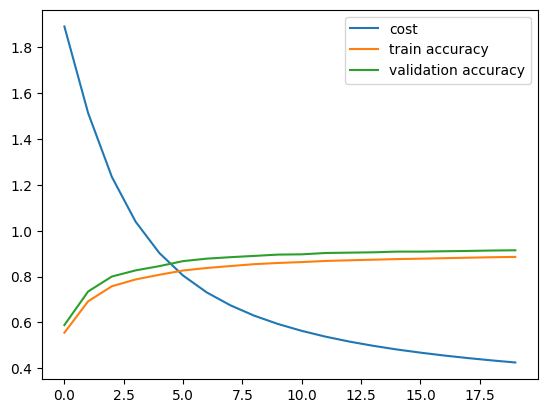

In [60]:
from matplotlib import pyplot as plt

plt.plot(range(20), stats["cost"], label="cost")
plt.plot(range(20), stats["train_acc"], label="train accuracy")
plt.plot(range(20), stats["valid_acc"], label="validation accuracy")

plt.legend()


(5) In diesem Schritt ist das Ziel, die größte Lernrate $\eta$ zu finden, für die das Netzwerk gerade noch trainierbar ist. Wir nutzen dazu folgende Heuristik:

1. Wählen Sie dazu zunächst einen *großen* Wert für die Lernrate $\eta$.
2. **Beobachten Sie beim Training den Verlauf der Kostenfunktion:** Steigt diese mit zunehmendem Training an? Unterbrechen Sie in diesem Fall das Training (unterbrechen Sie den Kernel) und wählen Sie eine kleinere Lernrate. Wiederholen Sie diesen Schritt, bis Sie beobachten, dass für eine gegebene Lernrate die Kostenfunktion während des Trainings beginnt abzusinken. Unterbrechen Sie wieder das Training.
3. Die aus dem vorherigen Schritt ermittelte Lernrate dividieren Sie durch 2. Dies ist die Lernrate, die Sie nun benutzten werden.

In [64]:
W1, b1, W2, b2, stats = train(train_images, train_labels, valid_images, valid_labels, epochs=20, n_layer1=100, minibatch_size=110, eta=1) #Ich habe gute Resultate mit eta=1 erzielt

20/20 | Cost: 0.02 | Train/Valid Acc.: 99.50%/97.70% 

(6) \[Optional\]: Variieren Sie auch den Parameter "Größe des Minibatches" und untersuchen Sie, ob und wie dieser das Training beeinflusst.

(7) \[Optional\]: Bestimmen Sie die Accuracy auf dem Testdatensatz, die Sie mit Ihrem am besten trainierten neuronalen Netz erzielt haben.

Damit darf ich Ihnen gratulieren! Sie haben ein Netz selbst implementiert und trainiert.

### 4.4 \[Optional\]  Ableitungen

Sie haben in Aufgabe 4.2 einige Ableitungen benutzt, die ich Ihnen vorgegeben habe. In dieser Aufgabe geht es darum, diese Ableitungen zu beweisen.

**Ihre Aufgaben**

(1) Sei $\sigma(s) = \frac{1}{1+e^{-s}}$ die Sigmoid-Funktion. Zeigen Sie, dass gilt: $$\frac{\mathrm{d}}{\mathrm{d}s} \sigma = \sigma(s) \cdot (1-\sigma(s))$$

(2) Die folgende Aufgabe ist etwas schreibaufwändiger. Sei die Kostenfunktion $$L=-\sum\limits_{i=1}^K y_i\log(o_i)$$ mit dem Softmax $$o_i = \frac{e^{v_i}}{\sum_{j=1}^K e^{v_j}}$$ gegeben. Zeigen Sie, dass gilt: $$ \frac{\partial L}{\partial v_i} = \sum\limits_{j=1}^{K} \frac{\partial L}{\partial o_j}\cdot \frac{\partial o_j}{\partial v_i} = o_i - y_i$$

Gehen Sie dabei in zwei Schritten vor.

Schritt 1: Zeigen Sie zunächst, dass gilt: $$\frac{\partial o_i}{\partial v_j} = \begin{cases}o_i(1-o_i) &\text{ für } i=j\\ -o_io_j & \text{ für } i\neq j\end{cases}$$

Schritt 2: Nutzen Sie das Ergebnis aus Schritt 1, um zu zeigen:

$$ \frac{\partial L}{\partial v_i} = \sum\limits_{j=1}^{K} \frac{\partial L}{\partial o_j}\cdot \frac{\partial o_j}{\partial v_i} = o_i - y_i$$